# SSH Chain Expert-Mode Benchmark

This notebook exercises the non-molecule expert-mode API with an open spinless Su-Schrieffer-Heeger (SSH) chain. The model uses alternating nearest-neighbor hoppings and is represented directly as a qubit Hamiltonian after the adjacent-site Jordan-Wigner mapping:

$$H = \frac{1}{2}\sum_i t_i (X_i X_{i+1} + Y_i Y_{i+1}),\quad t_i = t(1 + (-1)^i\delta).$$

The workflow compares exact diagonalization, VQE, VarQITE, and QPE for a small open chain. It is intentionally compact so it can serve as a template for other lattice Hamiltonians that do not pass through the molecule registry.

## Imports

In [12]:
from __future__ import annotations

import numpy as np
import pandas as pd
import pennylane as qml
import matplotlib.pyplot as plt

from common.benchmarks import timed_call
from qite.core import run_qite
from qpe.core import run_qpe
from vqe.core import run_vqe

In [13]:
N_SITES = 4
T = 1.0
DELTAS = [-0.9, -0.6, -0.3, 0.0, 0.3, 0.6, 0.9]

# Product half-filled reference used by VQE, VarQITE, and QPE.
REFERENCE_STATE = np.array([1, 0, 1, 0], dtype=int)

SEED = 0

# VQE parameters
VQE_STEPS = 150
VQE_STEPSIZE = 0.2

# VarQITE parameters
QITE_STEPS = 100
QITE_DTAU = 0.15

# Ansatz parameters
ANSATZ_NAME = "auto"
ANSATZ_KWARGS = {"layers": 4}

METHOD_STYLES = {
    "exact": {"color": "#222222", "marker": "o", "linestyle": "-"},
    "VQE": {"color": "#355070", "marker": "s", "linestyle": "--"},
    "VarQITE": {"color": "#2a9d8f", "marker": "^", "linestyle": "-."},
}

preview_delta = max(DELTAS, key=abs)
strong_bond = T * (1.0 + abs(preview_delta))
weak_bond = T * (1.0 - abs(preview_delta))


## SSH Chain Layout

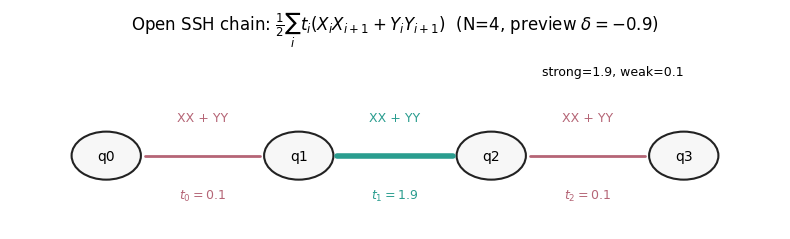

In [14]:
fig, ax = plt.subplots(figsize=(8, 2.5))

site_x = np.arange(N_SITES, dtype=float)
for wire, x in enumerate(site_x):
    ax.add_patch(plt.Circle((x, 0), 0.18, facecolor="#f7f7f7", edgecolor="#222222", linewidth=1.5))
    ax.text(x, 0.0, f"q{wire}", ha="center", va="center", fontsize=10)

for wire in range(N_SITES - 1):
    hopping = T * (1.0 + ((-1) ** wire) * preview_delta)
    is_strong = hopping >= T
    color = "#2a9d8f" if is_strong else "#b56576"
    linewidth = 4.0 if is_strong else 2.0
    label = rf"$t_{{{wire}}}={hopping:.1f}$"
    ax.plot([wire + 0.2, wire + 0.8], [0, 0], color=color, linewidth=linewidth, solid_capstyle="round")
    ax.text(wire + 0.5, 0.24, "XX + YY", ha="center", va="bottom", fontsize=9, color=color)
    ax.text(wire + 0.5, -0.24, label, ha="center", va="top", fontsize=9, color=color)

ax.text(N_SITES - 1.0, 0.58, rf"strong={strong_bond:.1f}, weak={weak_bond:.1f}", ha="right", va="bottom", fontsize=9)
ax.set_title(rf"Open SSH chain: $\frac{{1}}{{2}}\sum_i t_i(X_iX_{{i+1}} + Y_iY_{{i+1}})$  (N={N_SITES}, preview $\delta={preview_delta:+.1f}$)")
ax.set_xlim(-0.5, N_SITES - 0.5)
ax.set_ylim(-0.55, 0.8)
ax.axis("off")
fig.tight_layout()
plt.show()

## SSH Hamiltonian

In [15]:
def ssh_hamiltonian(num_sites: int, *, t: float, delta: float) -> qml.Hamiltonian:
    """Open spinless SSH chain after the adjacent-site Jordan-Wigner mapping."""
    if int(num_sites) < 2:
        raise ValueError("num_sites must be at least 2.")
    if abs(float(delta)) >= 1.0:
        raise ValueError("Use |delta| < 1 so both alternating hoppings remain positive.")

    coeffs = []
    ops = []
    for wire in range(int(num_sites) - 1):
        hopping = float(t) * (1.0 + ((-1) ** wire) * float(delta))
        coeffs.extend([0.5 * hopping, 0.5 * hopping])
        ops.extend(
            [
                qml.PauliX(wire) @ qml.PauliX(wire + 1),
                qml.PauliY(wire) @ qml.PauliY(wire + 1),
            ]
        )

    return qml.Hamiltonian(coeffs, ops)


def bond_hoppings(num_sites: int, *, t: float, delta: float) -> list[float]:
    return [float(t) * (1.0 + ((-1) ** wire) * float(delta)) for wire in range(num_sites - 1)]


def exact_lowest_energies(hamiltonian: qml.Hamiltonian, num_qubits: int, *, k: int = 3) -> np.ndarray:
    matrix = qml.matrix(hamiltonian, wire_order=list(range(int(num_qubits))))
    evals = np.linalg.eigvalsh(np.asarray(matrix, dtype=complex))
    return np.sort(np.real(evals))[: int(k)]

## Exact Reference Sweep

In [16]:
exact_rows = []
for delta in DELTAS:
    H = ssh_hamiltonian(N_SITES, t=T, delta=delta)
    lowest = exact_lowest_energies(H, N_SITES, k=3)
    exact_rows.append(
        {
            "delta": float(delta),
            "hoppings": bond_hoppings(N_SITES, t=T, delta=delta),
            "exact_ground_energy": float(lowest[0]),
            "exact_first_excited_energy": float(lowest[1]),
            "exact_gap": float(lowest[1] - lowest[0]),
            "hamiltonian_terms": len(H.ops),
        }
    )

exact_df = pd.DataFrame(exact_rows)
exact_df

,delta,hoppings,exact_ground_energy,exact_first_excited_energy,exact_gap,hamiltonian_terms
0,-0.9,"[0.09999999999999998, 1.9, 0.09999999999999998]",-1.910497,-1.905249,0.005249,6
1,-0.6,"[0.4, 1.6, 0.4]",-1.788854,-1.694427,0.094427,6
2,-0.3,"[0.7, 1.3, 0.7]",-1.910497,-1.605249,0.305249,6
3,0.0,"[1.0, 1.0, 1.0]",-2.236068,-1.618034,0.618034,6
4,0.3,"[1.3, 0.7, 1.3]",-2.692582,-1.696291,0.996291,6
5,0.6,"[1.6, 0.4, 1.6]",-3.224903,-1.812452,1.412452,6
6,0.9,"[1.9, 0.09999999999999998, 1.9]",-3.801316,-1.950658,1.850658,6


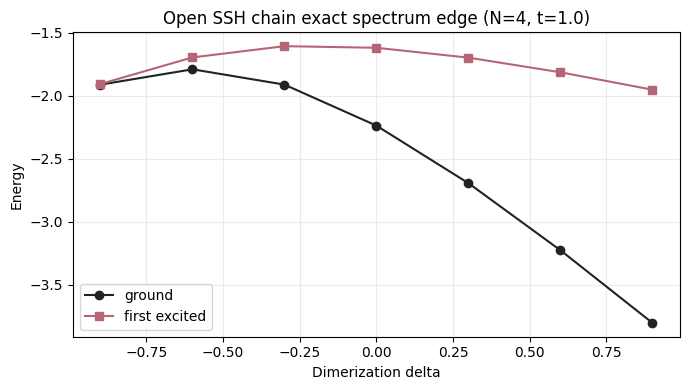

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(exact_df["delta"], exact_df["exact_ground_energy"], marker="o", color="#222222", label="ground")
ax.plot(exact_df["delta"], exact_df["exact_first_excited_energy"], marker="s", color="#b56576", label="first excited")
ax.set_xlabel("Dimerization delta")
ax.set_ylabel("Energy")
ax.set_title(f"Open SSH chain exact spectrum edge (N={N_SITES}, t={T})")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

## VQE Expert-Mode Sweep

In [18]:
vqe_rows = []
for delta in DELTAS:
    H = ssh_hamiltonian(N_SITES, t=T, delta=delta)
    result, elapsed = timed_call(
        run_vqe,
        suppress_stdout=True,
        molecule=f"SSH_N{N_SITES}_d{delta:+.2f}",
        hamiltonian=H,
        num_qubits=N_SITES,
        reference_state=REFERENCE_STATE,
        ansatz_name=ANSATZ_NAME,
        ansatz_kwargs=ANSATZ_KWARGS,
        optimizer_name="Adam",
        steps=VQE_STEPS,
        stepsize=VQE_STEPSIZE,
        seed=SEED,
        plot=False,
        force=False,
    )
    vqe_rows.append(
        {
            "delta": float(delta),
            "vqe_energy": float(result["energy"]),
            "vqe_runtime_s": float(result.get("compute_runtime_s", elapsed)),
            "vqe_final_energy_trace": result["energies"],
        }
    )

vqe_df = pd.DataFrame(vqe_rows)
vqe_df[["delta", "vqe_energy", "vqe_runtime_s"]]


,delta,vqe_energy,vqe_runtime_s
0,-0.9,-1.905275,17.956375
1,-0.6,-1.786690,17.770282
2,-0.3,-1.910490,16.479071
3,0.0,-2.236068,16.532435
4,0.3,-2.692582,16.614195
5,0.6,-3.224903,16.681353
6,0.9,-3.801315,16.620427


## VarQITE Expert-Mode Sweep

In [19]:
qite_rows = []
for delta in DELTAS:
    H = ssh_hamiltonian(N_SITES, t=T, delta=delta)
    result, elapsed = timed_call(
        run_qite,
        suppress_stdout=True,
        molecule=f"SSH_N{N_SITES}_d{delta:+.2f}",
        hamiltonian=H,
        num_qubits=N_SITES,
        reference_state=REFERENCE_STATE,
        ansatz_name=ANSATZ_NAME,
        ansatz_kwargs=ANSATZ_KWARGS,
        steps=QITE_STEPS,
        dtau=QITE_DTAU,
        seed=SEED,
        plot=False,
        show=False,
        force=False,
    )
    qite_rows.append(
        {
            "delta": float(delta),
            "qite_energy": float(result["energy"]),
            "qite_runtime_s": float(result.get("compute_runtime_s", elapsed)),
            "qite_final_energy_trace": result["energies"],
        }
    )

qite_df = pd.DataFrame(qite_rows)
qite_df[["delta", "qite_energy", "qite_runtime_s"]]


,delta,qite_energy,qite_runtime_s
0,-0.9,-1.906099,15.463158
1,-0.6,-1.788292,19.497439
2,-0.3,-1.910497,20.145907
3,0.0,-2.236068,15.582857
4,0.3,-2.692582,20.154218
5,0.6,-3.224903,17.388852
6,0.9,-3.801316,19.079162


## QPE Spot Checks

QPE is run only at representative dimerizations because it is shot based and uses controlled time evolution. The product reference is not an exact eigenstate, so the dominant phase should be interpreted as a diagnostic of overlap and resolution rather than as a guaranteed ground-state estimator.

In [20]:
QPE_DELTAS = [-0.6, 0.0, 0.6]
QPE_T = 0.8
QPE_ANCILLAS = 4
QPE_SHOTS = 1000
QPE_TROTTER_STEPS = 2

qpe_rows = []
for delta in QPE_DELTAS:
    H = ssh_hamiltonian(N_SITES, t=T, delta=delta)
    result, elapsed = timed_call(
        run_qpe,
        suppress_stdout=True,
        molecule=f"SSH_N{N_SITES}_d{delta:+.2f}",
        hamiltonian=H,
        hf_state=REFERENCE_STATE,
        system_qubits=N_SITES,
        n_ancilla=QPE_ANCILLAS,
        t=QPE_T,
        trotter_steps=QPE_TROTTER_STEPS,
        shots=QPE_SHOTS,
        seed=SEED,
        plot=False,
        force=False,
    )
    qpe_rows.append(
        {
            "delta": float(delta),
            "qpe_energy": float(result["energy"]),
            "qpe_best_bitstring": str(result["best_bitstring"]),
            "qpe_best_probability": float(result["probs"][result["best_bitstring"]]),
            "qpe_runtime_s": float(result.get("compute_runtime_s", elapsed)),
        }
    )

qpe_df = pd.DataFrame(qpe_rows)
qpe_df

,delta,qpe_energy,qpe_best_bitstring,qpe_best_probability,qpe_runtime_s
0,-0.6,1.472622,1101,0.257,0.280932
1,0.0,0.981748,1110,0.229,0.379688
2,0.6,0.000000,0000,0.215,0.445860


## Summary

In [21]:
summary = exact_df.merge(vqe_df.drop(columns=["vqe_final_energy_trace"]), on="delta")
summary = summary.merge(qite_df.drop(columns=["qite_final_energy_trace"]), on="delta")
summary["vqe_abs_error"] = (summary["vqe_energy"] - summary["exact_ground_energy"]).abs()
summary["qite_abs_error"] = (summary["qite_energy"] - summary["exact_ground_energy"]).abs()
summary

,delta,hoppings,exact_ground_energy,exact_first_excited_energy,exact_gap,hamiltonian_terms,vqe_energy,vqe_runtime_s,qite_energy,qite_runtime_s,vqe_abs_error,qite_abs_error
0,-0.9,"[0.09999999999999998, 1.9, 0.09999999999999998]",-1.910497,-1.905249,0.005249,6,-1.905275,17.956375,-1.906099,15.463158,5.221867e-03,4.397904e-03
1,-0.6,"[0.4, 1.6, 0.4]",-1.788854,-1.694427,0.094427,6,-1.786690,17.770282,-1.788292,19.497439,2.164233e-03,5.628153e-04
2,-0.3,"[0.7, 1.3, 0.7]",-1.910497,-1.605249,0.305249,6,-1.910490,16.479071,-1.910497,20.145907,7.371648e-06,2.562010e-09
3,0.0,"[1.0, 1.0, 1.0]",-2.236068,-1.618034,0.618034,6,-2.236068,16.532435,-2.236068,15.582857,1.369625e-07,8.881784e-16
4,0.3,"[1.3, 0.7, 1.3]",-2.692582,-1.696291,0.996291,6,-2.692582,16.614195,-2.692582,20.154218,3.794296e-07,2.220446e-15
5,0.6,"[1.6, 0.4, 1.6]",-3.224903,-1.812452,1.412452,6,-3.224903,16.681353,-3.224903,17.388852,3.619428e-08,1.332268e-15
6,0.9,"[1.9, 0.09999999999999998, 1.9]",-3.801316,-1.950658,1.850658,6,-3.801315,16.620427,-3.801316,19.079162,5.744783e-07,2.664535e-15


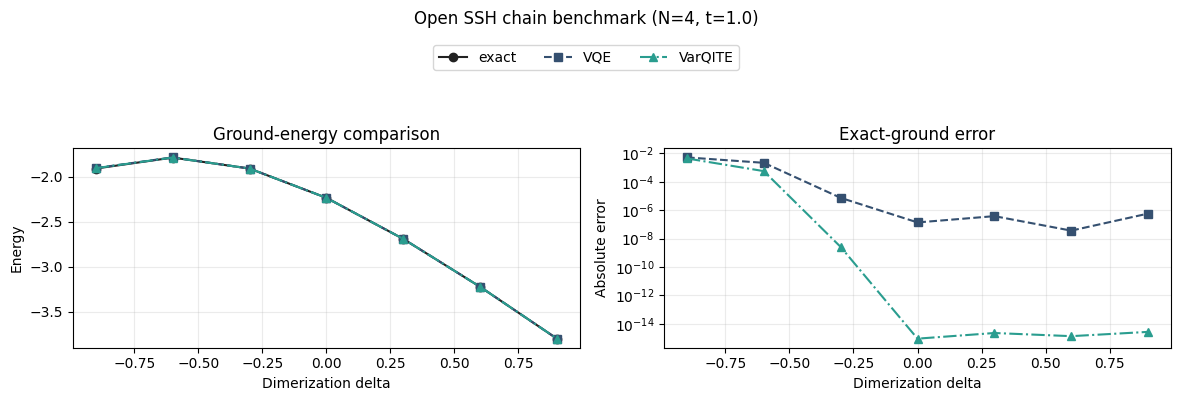

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

handles = []
labels = []

(line,) = axes[0].plot(summary["delta"], summary["exact_ground_energy"], label="exact", **METHOD_STYLES["exact"])
handles.append(line)
labels.append("exact")
(line,) = axes[0].plot(summary["delta"], summary["vqe_energy"], label="VQE", **METHOD_STYLES["VQE"])
handles.append(line)
labels.append("VQE")
(line,) = axes[0].plot(summary["delta"], summary["qite_energy"], label="VarQITE", **METHOD_STYLES["VarQITE"])
handles.append(line)
labels.append("VarQITE")
axes[0].set_xlabel("Dimerization delta")
axes[0].set_ylabel("Energy")
axes[0].set_title("Ground-energy comparison")
axes[0].grid(alpha=0.25)

axes[1].semilogy(summary["delta"], summary["vqe_abs_error"], label="VQE", **METHOD_STYLES["VQE"])
axes[1].semilogy(summary["delta"], summary["qite_abs_error"], label="VarQITE", **METHOD_STYLES["VarQITE"])
axes[1].set_xlabel("Dimerization delta")
axes[1].set_ylabel("Absolute error")
axes[1].set_title("Exact-ground error")
axes[1].grid(alpha=0.25, which="both")

fig.suptitle(f"Open SSH chain benchmark (N={N_SITES}, t={T})", y=0.99)
fig.legend(handles=handles, labels=labels, loc="upper center", ncol=len(handles), bbox_to_anchor=(0.5, 0.92))
fig.tight_layout(rect=[0, 0, 1, 0.82])

## Notes

- The open-chain SSH model is a useful non-molecule benchmark because the alternating bond pattern changes the gap while keeping the Hamiltonian small and exactly diagonalizable.
- The Hamiltonian is built locally, then passed to the solver APIs through expert mode with `hamiltonian=...` and `num_qubits=...` or `hf_state=...`.
- VQE and VarQITE use `ANSATZ_NAME = "auto"`; the selector should resolve this SSH Hamiltonian to `NumberPreservingGivens` with `ansatz_kwargs={"layers": 3}`. This is a better symmetry match for the half-filled SSH chain than a generic hardware-efficient ansatz because it preserves the excitation number of the reference state.
- For quantitative SSH studies, scan the number of Givens layers, optimizer settings, QITE time step, and system size rather than treating this four-site benchmark as converged physics.
- Increasing `N_SITES`, ansatz layers, QPE ancillas, or Trotter steps raises runtime quickly; keep this four-site version as a smoke benchmark before scaling.
